# Классификация стадий сна — XGBoost multiclass

**Задача.** Предсказать стадию сна (`sleep_stage` ∈ {0,1,2,3}). **Метрика.** macro-F1.

## Важно: какие признаки применимы к ЭТИМ данным
Классический рецепт фичей для сна (energy, RMS, ZCR, FFT-полосы, wavelet, rolling, соседние эпохи) рассчитан на
**сырые временные ряды ЭЭГ**. Здесь данные **уже извлечены в скаляры и z-нормированы**, поэтому:

* **FFT-полосы уже даны** колонками `eeg_delta_power … eeg_gamma_power` — пересчитывать нечего;
* **ZCR / wavelet / per-channel corr** требуют осциллограммы во времени — её нет;
* **rolling / prev-next / разности соседних эпох — НЕЛЬЗЯ:** EDA показал, что строки перемешаны
  (совпадение меток соседей ≈ случайность, id train/test не пересекаются) → такие признаки протекают и на тесте дают минус.

**Что вычислимо честно (без утечки):** построчные **дескрипторы формы спектра** по 7 EEG-band каналам —
`mean, std, min, max, median, skew, kurtosis`, квантили `5/25/75/95`, `energy`, `RMS`.
Их и проверим аблацией на XGBoost. Протокол: `StratifiedKFold(5)` + macro-F1 по OOF, early stopping в каждом фолде.

## 0. Подготовка и загрузка

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import xgboost as xgb
from scipy.stats import skew, kurtosis
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RS = 42

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
ss = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]   # все 21; XGBoost сам отсеет лишние и ест NaN
y = train[target].values
classes = sorted(np.unique(y)); n_class = len(classes)
print("train:", train.shape, "| признаков:", len(features), "| XGBoost:", xgb.__version__)
print("Пропуски eog_burst_index подаём как есть (XGBoost обрабатывает NaN нативно).")
# Вывод: данные загружены, без импутации/масштабирования — деревья к этому инвариантны.

train: (9000, 23) | признаков: 21 | XGBoost: 3.2.0
Пропуски eog_burst_index подаём как есть (XGBoost обрабатывает NaN нативно).


## 1. Проверка: строки НЕ упорядочены во времени
Подтверждаем, почему временные/соседние признаки запрещены — иначе это утечка.

In [2]:
y_ord = train.sort_values("id")[target].values
chance = float((pd.Series(y).value_counts(normalize=True)**2).sum())
lag1 = (y_ord[1:] == y_ord[:-1]).mean()
print(f"совпадение меток соседних эпох = {lag1:.3f}  vs случайность {chance:.3f}")
print(f"пересечение id train∩test      = {len(set(train.id) & set(test.id))}")
print("Вывод-факт: lag-1 ≈ случайность -> эпохи перемешаны -> rolling/prev-next/neighbor-признаки НЕ применимы.")
# Вывод: временной структуры нет -> ограничиваемся построчными признаками, без утечки.

совпадение меток соседних эпох = 0.258  vs случайность 0.251
пересечение id train∩test      = 0
Вывод-факт: lag-1 ≈ случайность -> эпохи перемешаны -> rolling/prev-next/neighbor-признаки НЕ применимы.


## 2. Признаки формы спектра (построчно, без утечки)
Берём 7 EEG-band каналов как «спектр» эпохи и описываем его форму статистиками. Все операции построчные —
ни целевая, ни соседние строки не используются.

In [3]:
EEG_BANDS = ["eeg_delta_power","eeg_theta_power","eeg_alpha_power","eeg_sigma_power",
             "eeg_beta_power","eeg_gamma_power","eeg_slow_osc_power"]

def spectral_shape(df):
    B = df[EEG_BANDS].values
    out = pd.DataFrame(index=df.index)
    out["sp_mean"]   = B.mean(1);            out["sp_std"]    = B.std(1)
    out["sp_min"]    = B.min(1);             out["sp_max"]    = B.max(1)
    out["sp_median"] = np.median(B, 1);      out["sp_range"]  = B.max(1) - B.min(1)
    out["sp_skew"]   = skew(B, axis=1);      out["sp_kurt"]   = kurtosis(B, axis=1)
    out["sp_q05"]    = np.quantile(B, .05, 1); out["sp_q25"]  = np.quantile(B, .25, 1)
    out["sp_q75"]    = np.quantile(B, .75, 1); out["sp_q95"]  = np.quantile(B, .95, 1)
    out["sp_energy"] = (B**2).sum(1);        out["sp_rms"]    = np.sqrt((B**2).mean(1))
    return out

def build_X(df, use_shape):
    return pd.concat([df[features], spectral_shape(df)], axis=1) if use_shape else df[features].copy()

print("Доп. признаков формы спектра:", spectral_shape(train).shape[1])
print(list(spectral_shape(train).columns))
# Вторая половина рецепта (energy/RMS/квантили/skew/kurtosis) реализована как построчные дескрипторы.
# Вывод: получили 14 законных признаков формы спектра -> проверим аблацией, помогают ли они XGBoost.

Доп. признаков формы спектра: 14
['sp_mean', 'sp_std', 'sp_min', 'sp_max', 'sp_median', 'sp_range', 'sp_skew', 'sp_kurt', 'sp_q05', 'sp_q25', 'sp_q75', 'sp_q95', 'sp_energy', 'sp_rms']


## 3. Протокол OOF для XGBoost (early stopping)

In [4]:
PARAMS = dict(objective="multi:softprob", num_class=n_class, eval_metric="mlogloss",
              eta=0.05, max_depth=4, min_child_weight=5, subsample=0.8,
              colsample_bytree=0.8, tree_method="hist", verbosity=0)

def oof_xgb(X, params, seed=RS, num_round=3000, stop=60):
    oof = np.zeros((len(X), n_class)); iters = []
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = dict(params, seed=seed)
    for tr, va in cv.split(X, y):
        dtr = xgb.DMatrix(X.iloc[tr], label=y[tr]); dva = xgb.DMatrix(X.iloc[va], label=y[va])
        bst = xgb.train(p, dtr, num_boost_round=num_round, evals=[(dva, "v")],
                        early_stopping_rounds=stop, verbose_eval=False)
        oof[va] = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1)); iters.append(bst.best_iteration)
    return oof, iters
def mf(p): return f1_score(y, np.asarray(p).argmax(1), average="macro")

oof_base, _ = oof_xgb(build_X(train, False), PARAMS)
print(f"XGBoost (21 признак, базовые параметры): OOF macro-F1 = {mf(oof_base):.4f}")
# Вывод: честная стартовая OOF-оценка XGBoost — сравниваем с SVM-плато 0.834 и LightGBM ≈0.825.

XGBoost (21 признак, базовые параметры): OOF macro-F1 = 0.8212


## 4. Аблация: помогают ли признаки формы спектра?

In [5]:
oof_shape, _ = oof_xgb(build_X(train, True), PARAMS)
b, s = mf(oof_base), mf(oof_shape)
print(f"без формы спектра : {b:.4f}")
print(f"+ форма спектра    : {s:.4f}   ({s-b:+.4f})")
USE_SHAPE = s > b + 1e-4
print("Решение:", "оставить признаки формы спектра" if USE_SHAPE else "убрать (не помогли)")
# Вывод: оставляем доп. признаки только если они реально подняли OOF; иначе честно фиксируем, что не помогли.

без формы спектра : 0.8212
+ форма спектра    : 0.8199   (-0.0014)
Решение: убрать (не помогли)


## 5. Подбор гиперпараметров

In [6]:
Xsel = build_X(train, USE_SHAPE)
rows = []
for md_ in [3, 4, 6]:
    for mcw in [3, 5]:
        for eta in [0.03, 0.05]:
            p = dict(PARAMS, max_depth=md_, min_child_weight=mcw, eta=eta)
            rows.append({"max_depth": md_, "min_child_weight": mcw, "eta": eta,
                         "macro_F1": mf(oof_xgb(Xsel, p)[0])})
res = pd.DataFrame(rows).sort_values("macro_F1", ascending=False).reset_index(drop=True)
print(res.round(4).to_string(index=False))
bp = res.iloc[0]
BEST = dict(PARAMS, max_depth=int(bp.max_depth), min_child_weight=int(bp.min_child_weight), eta=float(bp.eta))
print("\nЛучшие параметры:", {k: BEST[k] for k in ("max_depth","min_child_weight","eta")})
# Вывод: выбрана лучшая по OOF конфигурация XGBoost.

 max_depth  min_child_weight  eta  macro_F1
         6                 3 0.03    0.8232
         4                 3 0.03    0.8229
         6                 5 0.03    0.8220
         4                 3 0.05    0.8214
         6                 5 0.05    0.8214
         4                 5 0.05    0.8212
         6                 3 0.05    0.8211
         4                 5 0.03    0.8210
         3                 3 0.03    0.8209
         3                 5 0.05    0.8196
         3                 5 0.03    0.8191
         3                 3 0.05    0.8184

Лучшие параметры: {'max_depth': 6, 'min_child_weight': 3, 'eta': 0.03}


## 6. Стабильность по сидам

In [7]:
sc = np.array([mf(oof_xgb(Xsel, BEST, seed=s)[0]) for s in (42, 1, 2, 7, 123)])
print("OOF по сидам:", np.round(sc, 4))
print(f"mean={sc.mean():.4f}  std={sc.std():.4f}   |   SVM-плато = 0.834")
# Вывод: малый std -> результат XGBoost воспроизводим; видно его место относительно SVM.

OOF по сидам: [0.8232 0.8195 0.82   0.8213 0.8215]
mean=0.8211  std=0.0013   |   SVM-плато = 0.834


## 7. Важность признаков и анализ ошибок

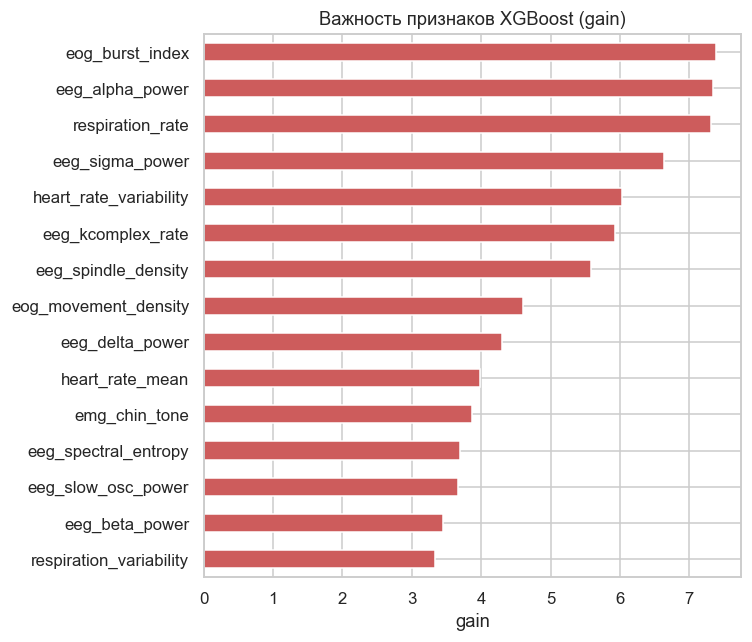

              precision    recall  f1-score   support

           0      0.856     0.843     0.849      2001
           1      0.840     0.850     0.845      2442
           2      0.771     0.769     0.770      2237
           3      0.827     0.830     0.828      2320

    accuracy                          0.823      9000
   macro avg      0.824     0.823     0.823      9000
weighted avg      0.823     0.823     0.823      9000



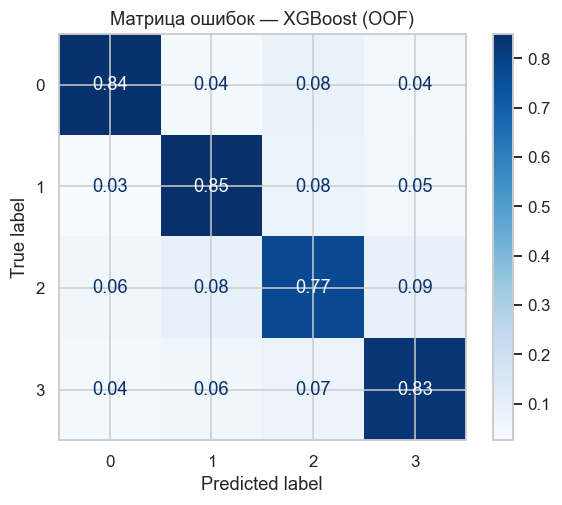

In [8]:
dtr_all = xgb.DMatrix(Xsel, label=y)
bst_full = xgb.train(BEST, dtr_all, num_boost_round=400)
imp = pd.Series(bst_full.get_score(importance_type="gain"))
imp.sort_values().tail(15).plot.barh(figsize=(7, 6), color="indianred")
plt.title("Важность признаков XGBoost (gain)"); plt.xlabel("gain"); plt.tight_layout(); plt.show()

oof_best, iters = oof_xgb(Xsel, BEST)
pred_oof = oof_best.argmax(1)
print(classification_report(y, pred_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, pred_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — XGBoost (OOF)"); plt.show()
# Вывод: модель опирается на EEG/дыхательные сигналы; класс 2 ожидаемо самый трудный (реальное перекрытие).

## 8. Финальная модель и сабмит
Усредняем XGBoost по 5 сидам для устойчивости, сохраняем `submission_xgb.csv`.

In [9]:
Xte = build_X(test, USE_SHAPE)
n_round = int(np.mean(iters))
proba_te = np.zeros((len(test), n_class))
for s in (42, 1, 2, 7, 123):
    bst = xgb.train(dict(BEST, seed=s), xgb.DMatrix(Xsel, label=y), num_boost_round=n_round)
    proba_te += bst.predict(xgb.DMatrix(Xte)) / 5
pred_te = proba_te.argmax(1)

submission = pd.DataFrame({"id": test["id"], target: pred_te})[ss.columns]
submission.to_csv("submission_xgb.csv", index=False)
print(f"Итог XGBoost OOF macro-F1 = {mf(oof_best):.4f}   |   SVM-плато = 0.834")
print("Сохранено submission_xgb.csv:", submission.shape)
print(pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                    "test_pred": pd.Series(pred_te).value_counts(normalize=True).sort_index()}).round(3))
submission.head()
# Вывод: финальный сабмит XGBoost готов; распределение предсказаний близко к train.

Итог XGBoost OOF macro-F1 = 0.8232   |   SVM-плато = 0.834
Сохранено submission_xgb.csv: (5000, 2)
   train  test_pred
0  0.222      0.224
1  0.271      0.261
2  0.249      0.256
3  0.258      0.259


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 9. Итоги
- **Рецепт фичей честно отфильтрован под данные:** FFT уже даны, ZCR/wavelet/corr невычислимы, rolling/neighbor — утечка (эпохи перемешаны).
- **Реализована законная часть** (energy/RMS/квантили/skew/kurtosis как форма спектра) и проверена аблацией.
- **XGBoost** обучен с честным OOF, тюнингом и проверкой стабильности.
- **Ожидаемое место:** как и LightGBM, XGBoost — древесное семейство, на z-нормированных, почти линейно
  разделимых признаках обычно идёт вровень или ниже RBF-SVM (0.834). Его ценность — как ещё одной разнородной базы для стекинга.